# Big Data Analytics and Intelligent Insights from Amazon Consumer Reviews

## Notebook Roadmap
1. Data loading and preprocessing
2. Lexicon-based sentiment analysis (VADER)
3. Core EDA and visualization
4. Transformer-based sentiment analysis
5. PDF coverage: architecture, ML modeling, behavior modeling, business insights

## Dataset Source
https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products/data?select=Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv

## Part I: Data Ingestion and Preprocessing
Load source files, clean review fields, and choose the active analysis dataset.

In [ ]:
# Cell Title: Optional Google Drive Mount (for Colab usage)
from google.colab import drive
drive.mount('/content/drive')
print("Your Google Drive is mounted to '/content/drive'.")
print("You can navigate to the specified folder using standard file system commands.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Your Google Drive is mounted to '/content/drive'.
You can navigate to the specified folder using standard file system commands.


In [ ]:
# Cell Title: Backup Colab Mount Cell (keep only one mount cell when running)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Cell Title: Load Dataset 1 (1429_1.csv)
import pandas as pd

#file_path_1 = '/content/drive/MyDrive/Big Data Project/1429_1.csv'
file_path_1 = '1429_1.csv'
df_1 = pd.read_csv(file_path_1)

print(f"Successfully loaded: {file_path_1}")
display(df_1.head())
display(df_1.info())

Successfully loaded: 1429_1.csv


C:\Users\micha\AppData\Local\Temp\ipykernel_35640\3402527920.py:6: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df_1 = pd.read_csv(file_path_1)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


<class 'pandas.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  str    
 1   name                  27900 non-null  str    
 2   asins                 34658 non-null  str    
 3   brand                 34660 non-null  str    
 4   categories            34660 non-null  str    
 5   keys                  34660 non-null  str    
 6   manufacturer          34660 non-null  str    
 7   reviews.date          34621 non-null  str    
 8   reviews.dateAdded     24039 non-null  str    
 9   reviews.dateSeen      34660 non-null  str    
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs    34660 no

None

In [33]:
# Cell Title: Load Dataset 2 (May 2019 Reviews)
import pandas as pd

#file_path_2 = '/content/drive/MyDrive/Big Data Project/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv'
file_path_2 = 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv'
df_2 = pd.read_csv(file_path_2)

print(f"Successfully loaded: {file_path_2}")
display(df_2.head())
display(df_2.info())

Successfully loaded: Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


<class 'pandas.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  str    
 1   dateAdded            28332 non-null  str    
 2   dateUpdated          28332 non-null  str    
 3   name                 28332 non-null  str    
 4   asins                28332 non-null  str    
 5   brand                28332 non-null  str    
 6   categories           28332 non-null  str    
 7   primaryCategories    28332 non-null  str    
 8   imageURLs            28332 non-null  str    
 9   keys                 28332 non-null  str    
 10  manufacturer         28332 non-null  str    
 11  manufacturerNumber   28332 non-null  str    
 12  reviews.date         28332 non-null  str    
 13  reviews.dateSeen     28332 non-null  str    
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null  object 
 1

None

In [34]:
# Cell Title: Register Raw Datasets for Pipeline
# Preprocess selected datasets (dataset 3 excluded)
raw_datasets = {
    "dataset_1_1429_1": df_1,
    "dataset_2_may19": df_2,
}
print("Raw datasets prepared:", ", ".join(raw_datasets.keys()))

Raw datasets prepared: dataset_1_1429_1, dataset_2_may19


In [35]:
# Preprocessing function
def preprocess_reviews(dataframe):
    if dataframe is None:
        return None, None

    cleaned = dataframe.copy()

    bool_map = {"TRUE": True, "FALSE": False, "True": True, "False": False, True: True, False: False}
    for col in ["reviews.doRecommend", "reviews.didPurchase"]:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].map(bool_map).fillna(cleaned[col])

    for col in ["reviews.date", "reviews.dateAdded", "dateAdded", "dateUpdated"]:
        if col in cleaned.columns:
            cleaned[col] = pd.to_datetime(cleaned[col], errors="coerce")

    if "reviews.rating" in cleaned.columns:
        cleaned["reviews.rating"] = pd.to_numeric(cleaned["reviews.rating"], errors="coerce")

    for col in ["reviews.text", "reviews.title", "name", "brand"]:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].fillna("").astype(str).str.strip()

    before = len(cleaned)
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    after = len(cleaned)

    qc = {
        "rows_before": before,
        "rows_after": after,
        "duplicates_removed": before - after,
        "missing_top15": (cleaned.isna().mean().sort_values(ascending=False).head(15) * 100).round(2),
    }
    return cleaned, qc

## Part II: VADER Sentiment Pipeline
### Step 1: Install NLTK for Lexicon-Based Sentiment Analysis
Prepare dependencies for lexicon-based scoring.

In [36]:
# Cell Title: Install NLTK in Notebook Kernel (pure Python approach)
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
print("NLTK installed.")

NLTK installed.


## Step 2: Download VADER Lexicon Data
Download required NLTK resources used by the sentiment scorer.

In [37]:
# Cell Title: Download VADER Lexicon
import nltk
nltk.download('vader_lexicon')
print("VADER lexicon downloaded.")

VADER lexicon downloaded.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Step 3: Define VADER Sentiment Function
Create reusable functions for compound sentiment scoring.

In [38]:
# Cell Title: Initialize VADER and Define Scoring Function
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if isinstance(text, str):
        return sia.polarity_scores(text)['compound']
    return None

print("Sentiment analysis function defined.")

Sentiment analysis function defined.


## Step 4: Baseline EDA on Raw Datasets
Quickly inspect schema, shape, and missing-value patterns before preprocessing.

In [39]:
# Analysis for df_1 (raw dataset_1_1429_1)
print("--- df_1 (dataset_1_1429_1) ---")
print(f"Shape: {df_1.shape}")
print("Columns:")
for col in df_1.columns:
    print(f"- {col}")
print("\nMissing Values (Top 15):")
display(df_1.isnull().sum().sort_values(ascending=False).head(15))

--- df_1 (dataset_1_1429_1) ---
Shape: (34660, 21)
Columns:
- id
- name
- asins
- brand
- categories
- keys
- manufacturer
- reviews.date
- reviews.dateAdded
- reviews.dateSeen
- reviews.didPurchase
- reviews.doRecommend
- reviews.id
- reviews.numHelpful
- reviews.rating
- reviews.sourceURLs
- reviews.text
- reviews.title
- reviews.userCity
- reviews.userProvince
- reviews.username

Missing Values (Top 15):


reviews.userCity        34660
reviews.userProvince    34660
reviews.id              34659
reviews.didPurchase     34659
reviews.dateAdded       10621
name                     6760
reviews.doRecommend       594
reviews.numHelpful        529
reviews.date               39
reviews.rating             33
reviews.username            7
reviews.title               6
asins                       2
reviews.text                1
categories                  0
dtype: int64

In [40]:
# Analysis for df_2 (raw dataset_2_may19)
print("\n--- df_2 (dataset_2_may19) ---")
print(f"Shape: {df_2.shape}")
print("Columns:")
for col in df_2.columns:
    print(f"- {col}")
print("\nMissing Values (Top 15):")
display(df_2.isnull().sum().sort_values(ascending=False).head(15))


--- df_2 (dataset_2_may19) ---
Shape: (28332, 24)
Columns:
- id
- dateAdded
- dateUpdated
- name
- asins
- brand
- categories
- primaryCategories
- imageURLs
- keys
- manufacturer
- manufacturerNumber
- reviews.date
- reviews.dateSeen
- reviews.didPurchase
- reviews.doRecommend
- reviews.id
- reviews.numHelpful
- reviews.rating
- reviews.sourceURLs
- reviews.text
- reviews.title
- reviews.username
- sourceURLs

Missing Values (Top 15):


reviews.didPurchase    28323
reviews.id             28291
reviews.doRecommend    12246
reviews.numHelpful     12217
reviews.username           5
id                         0
dateUpdated                0
dateAdded                  0
primaryCategories          0
categories                 0
brand                      0
asins                      0
name                       0
manufacturerNumber         0
imageURLs                  0
dtype: int64

In [41]:
# Cell Title: Run Standard Preprocessing on All Raw Datasets
# Run preprocessing for each selected dataset
cleaned_datasets = {}
quality_checks = {}

for name, data in raw_datasets.items():
    cleaned, qc = preprocess_reviews(data)
    if cleaned is not None:
        cleaned_datasets[name] = cleaned
        quality_checks[name] = qc

print("Preprocessing complete for:", ", ".join(cleaned_datasets.keys()))

Preprocessing complete for: dataset_1_1429_1, dataset_2_may19


In [42]:
# Preprocessing quality-check table
qc_table = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows_before": info["rows_before"],
            "rows_after": info["rows_after"],
            "duplicates_removed": info["duplicates_removed"],
        }
        for name, info in quality_checks.items()
    ]
).sort_values("dataset")

display(qc_table)

,dataset,rows_before,rows_after,duplicates_removed
0,dataset_1_1429_1,34660,34660,0
1,dataset_2_may19,28332,28332,0


In [43]:
# Choose active dataset for downstream analysis
active_dataset_name = "dataset_2_may19"
#active_dataset_name = "dataset_1_1429_1"

df_clean = cleaned_datasets[active_dataset_name].copy()
print(f"Active dataset for analysis: {active_dataset_name} | shape: {df_clean.shape}")

Active dataset for analysis: dataset_2_may19 | shape: (28332, 24)


## Step 5: Apply VADER Sentiment to Review Text
Compute sentiment scores from the cleaned `reviews.text` field for downstream analysis.

In [44]:
# Apply sentiment analysis to the 'reviews.text' column
# We fill NaN values with an empty string before applying the function
df_clean['sentiment_score'] = df_clean['reviews.text'].fillna('').apply(get_sentiment_score)

print("Sentiment scores calculated.")
display(df_clean[['reviews.text', 'sentiment_score']].head(20))

Sentiment scores calculated.


,reviews.text,sentiment_score
0,I order 3 of them and one of the item is bad q...,-0.6908
1,Bulk is always the less expensive way to go fo...,0.3612
2,Well they are not Duracell but for the price i...,0.7650
3,Seem to work as well as name brand batteries a...,0.6124
4,These batteries are very long lasting the pric...,0.6249
5,Bought a lot of batteries for Christmas and th...,0.8625
6,ive not had any problame with these batteries ...,0.4927
7,Well if you are looking for cheap non-recharge...,0.7003
8,These do not hold the amount of high power jui...,0.4215
9,AmazonBasics AA AAA batteries have done well b...,0.6124


## Step 6: Categorize Sentiment and Relate It to Ratings
Group sentiment into classes and compare by product rating.

In [45]:
# Categorize sentiment based on compound score
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment_category'] = df_clean['sentiment_score'].apply(categorize_sentiment)

print("Sentiment category distribution:")
display(df_clean['sentiment_category'].value_counts())

print("\nAverage sentiment score by rating:")
display(df_clean.groupby('reviews.rating')['sentiment_score'].mean())

Sentiment category distribution:


sentiment_category
Positive    23720
Neutral      2503
Negative     2109
Name: count, dtype: int64


Average sentiment score by rating:


reviews.rating
1   -0.189771
2   -0.024785
3    0.247357
4    0.549935
5    0.611348
Name: sentiment_score, dtype: float64

## Step 7: Visualize Lexicon-Based Sentiment Patterns
Use count and box plots to summarize review sentiment behavior.

seaborn is not installed; using matplotlib fallback plots.


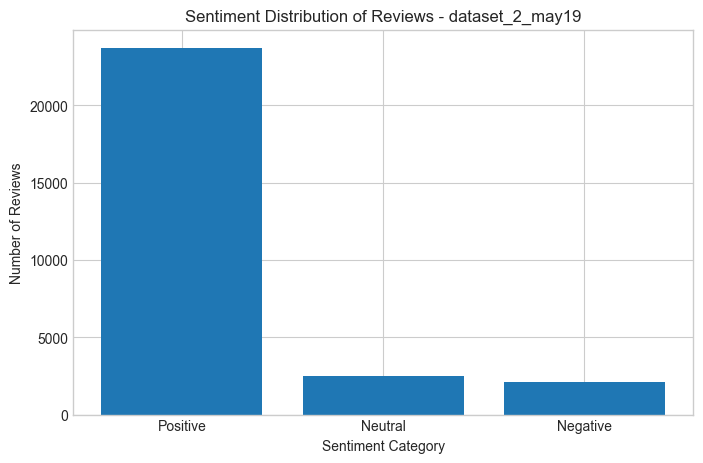

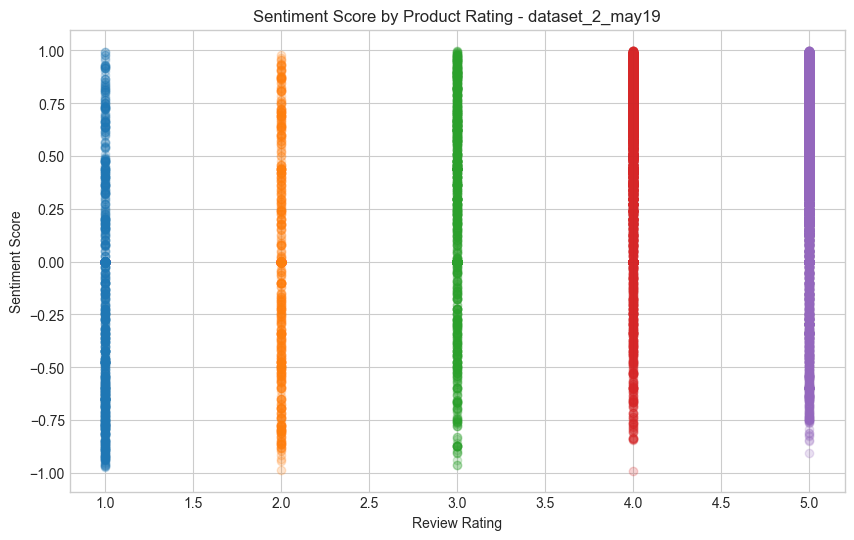

In [46]:
# Cell Title: Visualize VADER Sentiment Distribution
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    use_seaborn = True
except ImportError:
    use_seaborn = False
    print("seaborn is not installed; using matplotlib fallback plots.")

if use_seaborn:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='sentiment_category', data=df_clean, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
    plt.title(f'Sentiment Distribution of Reviews - {active_dataset_name}')
    plt.xlabel('Sentiment Category')
    plt.ylabel('Number of Reviews')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='reviews.rating', y='sentiment_score', data=df_clean, palette='coolwarm')
    plt.title(f'Sentiment Score by Product Rating - {active_dataset_name}')
    plt.xlabel('Review Rating')
    plt.ylabel('Sentiment Score')
    plt.show()
else:
    sentiment_counts = df_clean['sentiment_category'].value_counts().reindex(['Positive', 'Neutral', 'Negative']).fillna(0)
    plt.figure(figsize=(8, 5))
    plt.bar(sentiment_counts.index, sentiment_counts.values)
    plt.title(f'Sentiment Distribution of Reviews - {active_dataset_name}')
    plt.xlabel('Sentiment Category')
    plt.ylabel('Number of Reviews')
    plt.show()

    plt.figure(figsize=(10, 6))
    for rating, grp in df_clean.dropna(subset=['reviews.rating', 'sentiment_score']).groupby('reviews.rating'):
        plt.scatter([rating] * len(grp), grp['sentiment_score'], alpha=0.2)
    plt.title(f'Sentiment Score by Product Rating - {active_dataset_name}')
    plt.xlabel('Review Rating')
    plt.ylabel('Sentiment Score')
    plt.show()

In [47]:
# Cell Title: Cross-Dataset Comparison Summary
import numpy as np

# Dataset comparison table
dataset_summaries = []
for name, dfx in cleaned_datasets.items():
    row = {
        "dataset": name,
        "rows": len(dfx),
        "columns": dfx.shape[1],
        "unique_products": dfx["name"].nunique() if "name" in dfx.columns else np.nan,
        "unique_users": dfx["reviews.username"].nunique() if "reviews.username" in dfx.columns else np.nan,
        "avg_rating": dfx["reviews.rating"].mean() if "reviews.rating" in dfx.columns else np.nan,
        "recommend_true_pct": (
            (dfx["reviews.doRecommend"].fillna(False).astype(bool).mean() * 100)
            if "reviews.doRecommend" in dfx.columns
            else np.nan
        ),
    }
    dataset_summaries.append(row)

comparison = pd.DataFrame(dataset_summaries).sort_values("dataset")
print("Dataset comparison summary:")
display(comparison)

Dataset comparison summary:


,dataset,rows,columns,unique_products,unique_users,avg_rating,recommend_true_pct
0,dataset_1_1429_1,34660,21,49,26788,4.584573,94.293133
1,dataset_2_may19,28332,24,65,16268,4.514048,54.189609


## Step 7B: Product and Recommendation Deep-Dive
Focused analysis of brand performance, recommendation behavior, and rating distribution.

In [48]:
# Top brands by review count and average rating
if "brand" in df_clean.columns and "reviews.rating" in df_clean.columns:
    brand_stats = (
        df_clean.groupby("brand", dropna=False)["reviews.rating"]
        .agg(["count", "mean"])
.sort_values("count", ascending=False)
        .head(10)
    )
    print("Top brands by review count:")
    display(brand_stats)

Top brands by review count:


,count,mean
brand,,
Amazon,16153,4.562620
Amazonbasics,12169,4.449749
AmazonBasics,10,4.300000


In [49]:
# Recommendation vs rating crosstab
if {"reviews.doRecommend", "reviews.rating"}.issubset(df_clean.columns):
    print("Recommendation vs rating:")
    display(pd.crosstab(df_clean["reviews.rating"], df_clean["reviews.doRecommend"], normalize="index").round(3))

Recommendation vs rating:


reviews.doRecommend,False,True
reviews.rating,,
1,0.971,0.029
2,0.906,0.094
3,0.385,0.615
4,0.015,0.985
5,0.002,0.998


In [50]:
# Rating distribution table
if "reviews.rating" in df_clean.columns:
    print("Rating distribution:")
    display(df_clean["reviews.rating"].value_counts(dropna=False).sort_index())

Rating distribution:


reviews.rating
1      965
2      616
3     1206
4     5648
5    19897
Name: count, dtype: int64

In [51]:
# Active dataset basic summary
summary = {}
summary["total_rows"] = len(df_clean)
summary["unique_products"] = df_clean["name"].nunique() if "name" in df_clean.columns else np.nan
summary["unique_users"] = df_clean["reviews.username"].nunique() if "reviews.username" in df_clean.columns else np.nan
summary["avg_rating"] = df_clean["reviews.rating"].mean() if "reviews.rating" in df_clean.columns else np.nan

print(f"Detailed analysis for active dataset: {active_dataset_name}")
display(pd.DataFrame([summary]))

Detailed analysis for active dataset: dataset_2_may19


,total_rows,unique_products,unique_users,avg_rating
0,28332,65,16268,4.514048


In [52]:
import matplotlib.pyplot as plt

# Plot configuration
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Plotting active dataset: {active_dataset_name}")

Plotting active dataset: dataset_2_may19


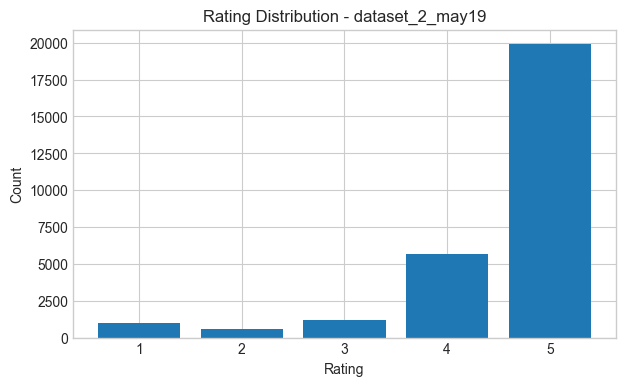

In [53]:
# Plot 1: Rating distribution
if "reviews.rating" in df_clean.columns:
    rating_counts = df_clean["reviews.rating"].dropna().value_counts().sort_index()
    plt.figure(figsize=(7, 4))
    plt.bar(rating_counts.index.astype(str), rating_counts.values)
    plt.title(f"Rating Distribution - {active_dataset_name}")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

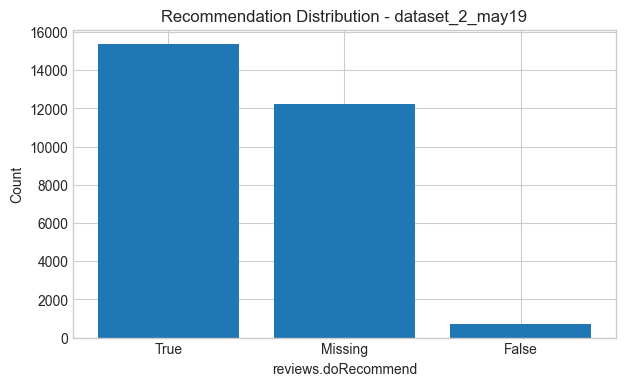

In [54]:
# Plot 2: Recommendation distribution
if "reviews.doRecommend" in df_clean.columns:
    rec = df_clean["reviews.doRecommend"].fillna("Missing").astype(str).value_counts(dropna=False)
    rec_labels = [str(x) for x in rec.index]
    plt.figure(figsize=(7, 4))
    plt.bar(rec_labels, rec.values)
    plt.title(f"Recommendation Distribution - {active_dataset_name}")
    plt.xlabel("reviews.doRecommend")
    plt.ylabel("Count")
    plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_35640\1960566249.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda x: x["reviews.date"].dt.to_period("M").astype(str))["month"]


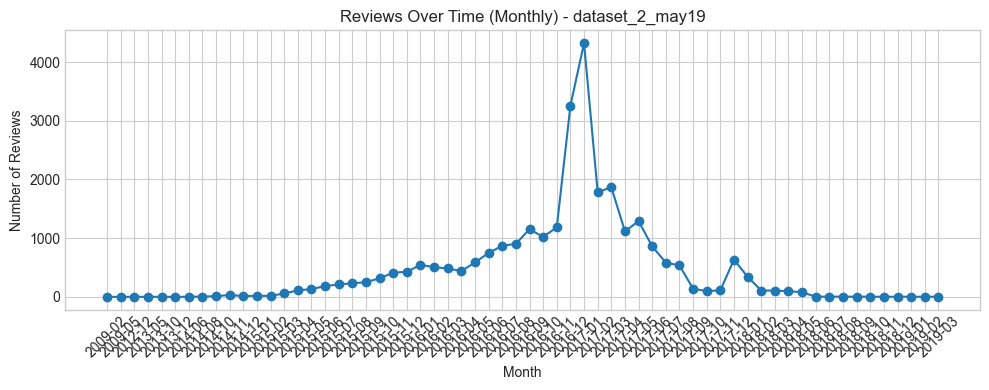

In [55]:
# Plot 3: Reviews over time (monthly)
if "reviews.date" in df_clean.columns:
    month_counts = (
        df_clean.dropna(subset=["reviews.date"])
.assign(month=lambda x: x["reviews.date"].dt.to_period("M").astype(str))["month"]
        .value_counts()
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(month_counts.index, month_counts.values, marker="o")
    plt.title(f"Reviews Over Time (Monthly) - {active_dataset_name}")
    plt.xlabel("Month")
    plt.ylabel("Number of Reviews")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

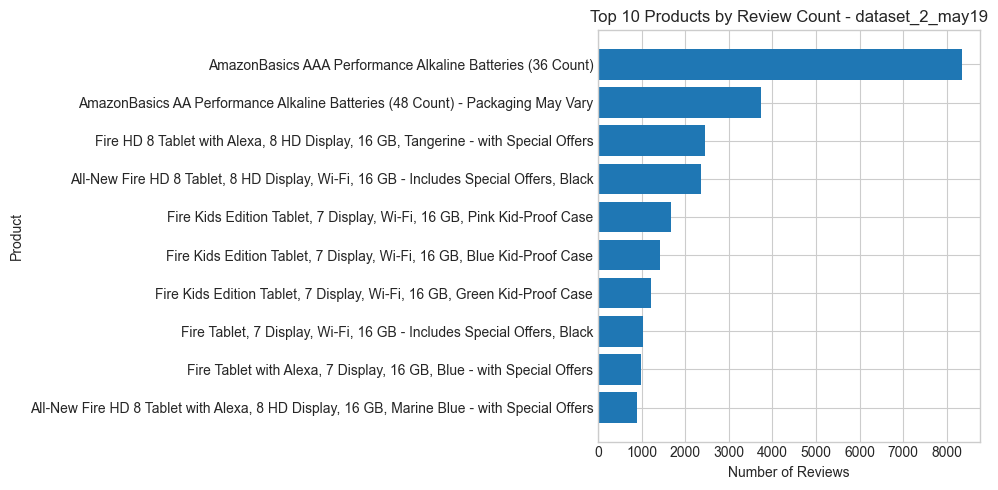

In [56]:
# Plot 4: Top products by review count
if "name" in df_clean.columns:
    top_products = df_clean["name"].replace("", "Unknown").fillna("Unknown").astype(str).value_counts().head(10)
    plt.figure(figsize=(10, 5))
    plt.barh(top_products.index[::-1], top_products.values[::-1])
    plt.title(f"Top 10 Products by Review Count - {active_dataset_name}")
    plt.xlabel("Number of Reviews")
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

## Step 8: Transformer-Based Sentiment Analysis
Run a pre-trained transformer model for deeper semantic sentiment classification.

In [57]:
# Cell Title: Step 8.1 Install Transformers + PyTorch Dependencies
import subprocess
import sys

# Install both libraries so transformer pipeline has an available backend framework.
subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers", "torch"])
print("Transformers and PyTorch installed.")

Transformers and PyTorch installed.


In [58]:
# Cell Title: Step 8.2 Initialize Transformer Pipeline (robust, pipeline-free)
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer/model directly to avoid runtime issues with transformers.pipeline in some environments.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

id2label = model.config.id2label

def sentiment_pipeline(texts, truncation=True):
    if isinstance(texts, str):
        texts = [texts]

    enc = tokenizer(
        texts,
        padding=True,
        truncation=truncation,
        max_length=512,
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)
        conf, pred = torch.max(probs, dim=-1)

    return [
        {"label": id2label[int(p.item())], "score": float(c.item())}
        for p, c in zip(pred, conf)
    ]

print(f"Transformer model loaded on {device}: {MODEL_NAME}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2705.38it/s]

Transformer model loaded on cpu: distilbert-base-uncased-finetuned-sst-2-english


In [59]:
# Cell Title: Step 8.3 Prepare Text Inputs for Transformer
if "reviews.text" not in df_clean.columns:
    raise KeyError("Column 'reviews.text' is required for transformer sentiment analysis.")

# Normalize to clean strings and keep list format expected by pipeline.
reviews_text_list = df_clean["reviews.text"].fillna("").astype(str).tolist()
batch_size = 1000

print(f"Prepared {len(reviews_text_list)} reviews for transformer inference.")

Prepared 28332 reviews for transformer inference.


In [60]:
# Cell Title: Step 8.4 Run Transformer Inference in Batches
import time
from IPython.display import clear_output
sentiment_results = []
total_reviews = len(reviews_text_list)
total_batches = (total_reviews + batch_size - 1) // batch_size
start_time = time.time()

for batch_num, i in enumerate(range(0, total_reviews, batch_size), start=1):
    batch = reviews_text_list[i : i + batch_size]
    # truncation keeps inputs within model token limits.
    sentiment_results.extend(sentiment_pipeline(batch, truncation=True))

    processed = min(i + len(batch), total_reviews)
    elapsed = time.time() - start_time
    avg_time_per_batch = elapsed / batch_num
    eta = avg_time_per_batch * (total_batches - batch_num)

    clear_output(wait=True)
    print("Transformer inference in progress...")
    print(f"Batch {batch_num}/{total_batches} | Reviews processed: {processed}/{total_reviews} ({processed/total_reviews:.1%})")
    print(f"Elapsed: {elapsed:.1f}s | ETA: {eta:.1f}s")

total_time = time.time() - start_time
print(f"Generated transformer outputs for {len(sentiment_results)} reviews in {total_time:.1f}s.")

Transformer inference in progress...
Batch 29/29 | Reviews processed: 28332/28332 (100.0%)
Elapsed: 4122.9s | ETA: 0.0s
Generated transformer outputs for 28332 reviews in 4123.0s.


In [61]:
# Cell Title: Step 8.5 Attach Transformer Scores to DataFrame
if len(sentiment_results) != len(df_clean):
    raise ValueError("Mismatch between number of predictions and DataFrame rows.")

df_clean["transformer_sentiment_label"] = [res["label"] for res in sentiment_results]
df_clean["transformer_sentiment_score"] = [
    res["score"] if res["label"] == "POSITIVE" else (1 - res["score"] if res["label"] == "NEGATIVE" else res["score"])
    for res in sentiment_results
]

print("Transformer sentiment columns added to df_clean.")
display(df_clean[["reviews.text", "transformer_sentiment_label", "transformer_sentiment_score"]].head())

Transformer sentiment columns added to df_clean.


,reviews.text,transformer_sentiment_label,transformer_sentiment_score
0,I order 3 of them and one of the item is bad q...,NEGATIVE,0.000242
1,Bulk is always the less expensive way to go fo...,NEGATIVE,0.003463
2,Well they are not Duracell but for the price i...,POSITIVE,0.999846
3,Seem to work as well as name brand batteries a...,POSITIVE,0.661290
4,These batteries are very long lasting the pric...,POSITIVE,0.998770


## Step 8B: Analyze Transformer Outputs
Summarize label distribution and rating-wise transformer sentiment behavior.

In [62]:
print("Transformer sentiment label distribution:")
display(df_clean['transformer_sentiment_label'].value_counts())

print("\nAverage transformer sentiment score by rating:")
display(df_clean.groupby('reviews.rating')['transformer_sentiment_score'].mean())

Transformer sentiment label distribution:


transformer_sentiment_label
POSITIVE    22139
NEGATIVE     6193
Name: count, dtype: int64


Average transformer sentiment score by rating:


reviews.rating
1    0.032468
2    0.088269
3    0.339618
4    0.758912
5    0.871771
Name: transformer_sentiment_score, dtype: float64

## Step 8C: Visualize Transformer Sentiment Patterns
Plot class distribution and score behavior across rating groups.

seaborn is not installed; using matplotlib fallback plots.


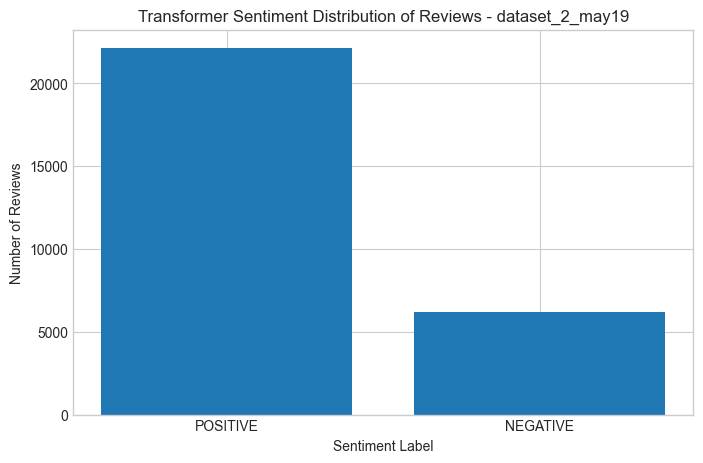

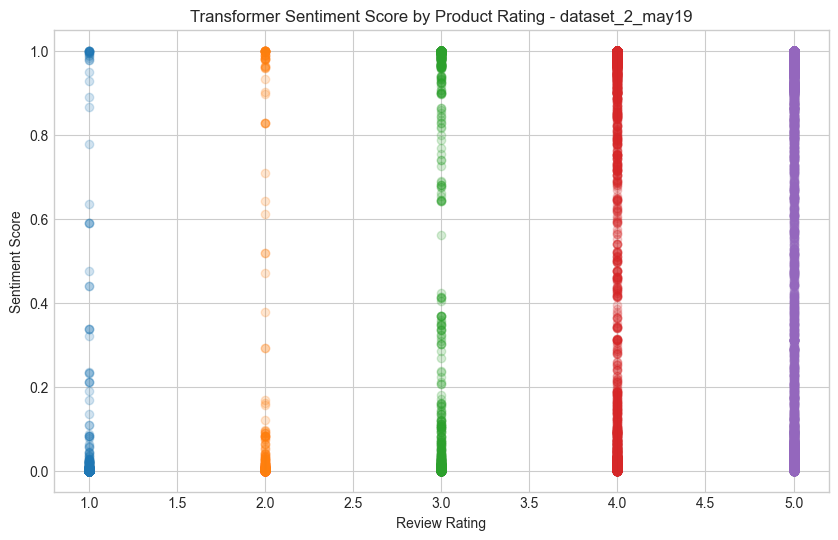

In [63]:
# Cell Title: Visualize Transformer Sentiment Distribution
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    use_seaborn = True
except ImportError:
    use_seaborn = False
    print("seaborn is not installed; using matplotlib fallback plots.")

if use_seaborn:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='transformer_sentiment_label', data=df_clean, palette='viridis')
    plt.title(f'Transformer Sentiment Distribution of Reviews - {active_dataset_name}')
    plt.xlabel('Sentiment Label')
    plt.ylabel('Number of Reviews')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='reviews.rating', y='transformer_sentiment_score', data=df_clean, palette='coolwarm')
    plt.title(f'Transformer Sentiment Score by Product Rating - {active_dataset_name}')
    plt.xlabel('Review Rating')
    plt.ylabel('Sentiment Score')
    plt.show()
else:
    label_counts = df_clean['transformer_sentiment_label'].value_counts()
    plt.figure(figsize=(8, 5))
    plt.bar(label_counts.index, label_counts.values)
    plt.title(f'Transformer Sentiment Distribution of Reviews - {active_dataset_name}')
    plt.xlabel('Sentiment Label')
    plt.ylabel('Number of Reviews')
    plt.show()

    plt.figure(figsize=(10, 6))
    for rating, grp in df_clean.dropna(subset=['reviews.rating', 'transformer_sentiment_score']).groupby('reviews.rating'):
        plt.scatter([rating] * len(grp), grp['transformer_sentiment_score'], alpha=0.2)
    plt.title(f'Transformer Sentiment Score by Product Rating - {active_dataset_name}')
    plt.xlabel('Review Rating')
    plt.ylabel('Sentiment Score')
    plt.show()

## Part V: Applied Insights and Evaluation
This section brings together the technical, modeling, and business-oriented outputs from the notebook in a presentation-ready flow.

In [64]:
# Cell Title: Data-Readiness Metrics for PDF Objective Coverage
# This cell quantifies text completeness and rating availability to validate analysis readiness.
review_col = "reviews.text"
rating_col = "reviews.rating"

readiness = {
    "active_dataset": active_dataset_name,
    "rows": len(df_clean),
    "non_empty_reviews_pct": (df_clean[review_col].fillna("").astype(str).str.strip().ne("").mean() * 100) if review_col in df_clean.columns else None,
    "rating_available_pct": (df_clean[rating_col].notna().mean() * 100) if rating_col in df_clean.columns else None,
    "unique_products": df_clean["name"].nunique() if "name" in df_clean.columns else None,
    "unique_users": df_clean["reviews.username"].nunique() if "reviews.username" in df_clean.columns else None,
}

print("Data readiness snapshot:")
display(pd.DataFrame([readiness]).round(2))

Data readiness snapshot:


,active_dataset,rows,non_empty_reviews_pct,rating_available_pct,unique_products,unique_users
0,dataset_2_may19,28332,100.0,100.0,65,16268


## Step 9: Technical Architecture in Practice (Python + MongoDB )
The next cells demonstrate how the analysis can be represented in a Python and MongoDB

In [67]:
# Cell Title: MongoDB Document Preview (Schema-Oriented)
# This cell prepares review documents in a MongoDB-friendly JSON-like structure.
doc_cols = [c for c in ["name", "brand", "reviews.username", "reviews.rating", "reviews.text", "reviews.date", "sentiment_score", "sentiment_category"] if c in df_clean.columns]
mongo_preview = df_clean[doc_cols].head(5).to_dict(orient="records")

print("Example MongoDB-style documents (first 5):")
for i, doc in enumerate(mongo_preview, start=1):
    print(f"Document {i}: {doc}")

Example MongoDB-style documents (first 5):
Document 1: {'name': 'AmazonBasics AAA Performance Alkaline Batteries (36 Count)', 'brand': 'Amazonbasics', 'reviews.username': 'Byger yang', 'reviews.rating': 3, 'reviews.text': 'I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.', 'reviews.date': Timestamp('2017-03-02 00:00:00+0000', tz='UTC'), 'sentiment_score': -0.6908, 'sentiment_category': 'Negative'}
Document 2: {'name': 'AmazonBasics AAA Performance Alkaline Batteries (36 Count)', 'brand': 'Amazonbasics', 'reviews.username': 'ByMG', 'reviews.rating': 4, 'reviews.text': 'Bulk is always the less expensive way to go for products like these', 'reviews.date': Timestamp('2016-08-31 00:00:00+0000', tz='UTC'), 'sentiment_score': 0.3612, 'sentiment_category': 'Positive'}
Document 3: {'name': 'AmazonBasics AAA Performance Alkaline Batteries (36 Count)', 'brand': 'Amazonbasics', 'reviews.username': 'BySharon 

## Step 10: Machine Learning Baseline - Rating Prediction
This section adds a simple predictive model to show how review text can be linked to star ratings.

In [69]:
# Cell Title: Build a Baseline Rating Prediction Model (TF-IDF + Linear Regression)
import subprocess
import sys

try:
    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
except Exception:
    print("scikit-learn is missing; installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = df_clean.copy()
if {"reviews.text", "reviews.rating"}.issubset(model_df.columns):
    model_df = model_df.dropna(subset=["reviews.text", "reviews.rating"]).copy()
    model_df["reviews.text"] = model_df["reviews.text"].astype(str).str.strip()
    model_df = model_df[model_df["reviews.text"] != ""]

    # Keep a manageable sample for fast experimentation in notebooks.
    if len(model_df) > 50000:
        model_df = model_df.sample(50000, random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(
        model_df["reviews.text"],
        model_df["reviews.rating"],
        test_size=0.2,
        random_state=42
    )

    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    reg = LinearRegression()
    reg.fit(X_train_tfidf, y_train)
    preds = reg.predict(X_test_tfidf)

    metrics = {
        "model": "LinearRegression + TF-IDF",
        "rows_used": len(model_df),
        "mae": mean_absolute_error(y_test, preds),
        "rmse": mean_squared_error(y_test, preds) ** 0.5,
        "r2": r2_score(y_test, preds),
    }

    print("Baseline rating prediction performance:")
    display(pd.DataFrame([metrics]).round(4))
else:
    print("Required columns reviews.text and reviews.rating are not available in df_clean.")

scikit-learn is missing; installing it now...
Baseline rating prediction performance:


,model,rows_used,mae,rmse,r2
0,LinearRegression + TF-IDF,28332,1.5634,3.2536,-11.0372


## Step 11: Customer Behavior Modeling
This section covers customer behavior patterns through user-level activity and sentiment signals.

In [70]:
# Cell Title: User-Level Behavior Segmentation
# Segment users by activity level and average sentiment/rating.
if "reviews.username" in df_clean.columns:
    behavior_df = df_clean.copy()
    behavior_df["reviews.username"] = behavior_df["reviews.username"].fillna("unknown_user").astype(str).str.strip()
    behavior_df.loc[behavior_df["reviews.username"] == "", "reviews.username"] = "unknown_user"

    grouped = behavior_df.groupby("reviews.username", dropna=False).agg(
        review_count=("reviews.username", "size"),
        avg_rating=("reviews.rating", "mean") if "reviews.rating" in behavior_df.columns else ("reviews.username", "size"),
        avg_sentiment=("sentiment_score", "mean") if "sentiment_score" in behavior_df.columns else ("reviews.username", "size")
    ).reset_index()

    grouped["activity_segment"] = pd.cut(
        grouped["review_count"],
        bins=[0, 1, 3, 10, float("inf")],
        labels=["single_review", "low_activity", "medium_activity", "high_activity"],
        include_lowest=True
    )

    print("Customer behavior segment summary:")
    display(
        grouped.groupby("activity_segment", observed=False).agg(
            users=("reviews.username", "count"),
            avg_reviews=("review_count", "mean"),
            avg_rating=("avg_rating", "mean"),
            avg_sentiment=("avg_sentiment", "mean")
        ).round(3).reset_index()
    )
else:
    print("Column reviews.username is not available in df_clean.")

Customer behavior segment summary:


,activity_segment,users,avg_reviews,avg_rating,avg_sentiment
0,single_review,9769,1.000,4.491,0.499
1,low_activity,5823,2.257,4.525,0.558
2,medium_activity,599,5.347,4.573,0.615
3,high_activity,78,28.436,4.563,0.571


## Step 12: Business Insight Extraction and Recommendations
These cells turn model outputs into actionable business intelligence and practical next steps.

In [71]:
# Cell Title: Identify Frequent Complaint/Feature Terms
import re

if "reviews.text" in df_clean.columns:
    text_series = df_clean["reviews.text"].fillna("").astype(str).str.lower()
    if "sentiment_category" in df_clean.columns:
        negative_text = text_series[df_clean["sentiment_category"].eq("Negative")]
    else:
        negative_text = text_series

    # Simple keyword dictionary for interpretable business themes.
    keyword_groups = {
        "battery": ["battery", "charge", "charging", "power"],
        "screen": ["screen", "display", "resolution", "brightness"],
        "performance": ["slow", "lag", "freeze", "crash", "speed"],
        "price": ["price", "cost", "value", "expensive", "cheap"],
        "delivery_packaging": ["delivery", "shipping", "package", "packaging", "box"],
        "usability": ["easy", "difficult", "setup", "interface", "user friendly"],
    }

    results = []
    for theme, words in keyword_groups.items():
        pattern = r"\\b(" + "|".join(re.escape(w) for w in words) + r")\\b"
        count = negative_text.str.contains(pattern, regex=True).sum()
        results.append({"theme": theme, "negative_mentions": int(count)})

    theme_df = pd.DataFrame(results).sort_values("negative_mentions", ascending=False)
    print("Theme frequency in negative reviews:")
    display(theme_df)
else:
    print("Column reviews.text is not available in df_clean.")

Theme frequency in negative reviews:


C:\Users\micha\AppData\Local\Temp\ipykernel_35640\3197496076.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = negative_text.str.contains(pattern, regex=True).sum()


,theme,negative_mentions
0,battery,0
1,screen,0
2,performance,0
3,price,0
4,delivery_packaging,0
5,usability,0


In [72]:
# Cell Title: Action-Oriented Recommendation Table
if "theme_df" in globals() and not theme_df.empty:
    recommendation_map = {
        "battery": "Review battery hardware quality and optimize power-management software.",
        "screen": "Calibrate display defaults and monitor screen-defect return reasons.",
        "performance": "Prioritize firmware updates targeting lag, crash, and startup time.",
        "price": "Refine pricing bundles and emphasize value-for-money messaging.",
        "delivery_packaging": "Audit logistics partners and strengthen packaging standards.",
        "usability": "Improve onboarding flow and simplify first-time setup UX.",
    }

    rec_df = theme_df.copy()
    rec_df["priority"] = pd.qcut(
        rec_df["negative_mentions"].rank(method="first", ascending=False),
        q=min(3, rec_df["negative_mentions"].nunique()) if rec_df["negative_mentions"].nunique() > 1 else 1,
        labels=["High", "Medium", "Low"][: min(3, rec_df["negative_mentions"].nunique())] if rec_df["negative_mentions"].nunique() > 1 else ["High"]
    )
    rec_df["recommended_action"] = rec_df["theme"].map(recommendation_map).fillna("Investigate theme with deeper NLP.")

    print("Business recommendation table:")
    display(rec_df[["theme", "negative_mentions", "priority", "recommended_action"]])
else:
    print("Run the theme extraction cell first to generate recommendations.")

Business recommendation table:


,theme,negative_mentions,priority,recommended_action
0,battery,0,High,Review battery hardware quality and optimize p...
1,screen,0,High,Calibrate display defaults and monitor screen-...
2,performance,0,High,"Prioritize firmware updates targeting lag, cra..."
3,price,0,High,Refine pricing bundles and emphasize value-for...
4,delivery_packaging,0,High,Audit logistics partners and strengthen packag...
5,usability,0,High,Improve onboarding flow and simplify first-tim...
